The junction is modeled as a one-dimensional silicon p-n junction at thermal equilibrium. Unlike the abrupt-junction model, the doping concentration varies continuously.

Like the abrupt-junction model, The p-side is to the left of the junction and the n-side is to the right.

However, unlike the abrupt-junction model, the charge density $\rho$ is now a function of electrostatic potential $\phi$ instead of position $x$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
q = 1.602e-19 #charge (C)
PERMITTIVITY = 8.854e-12 #permittivity constant (F/m)
epsilon = 11.7*PERMITTIVITY #permittivity of silicon (F/m)
k = 1.381e-23 #boltzmann constant (J/k)
T = 300 #Temperature (K)
n_i = 1e10 * 1e6 #intrinsic carrier concentration of silicon converted to SI units (m^-3)

The device is represented by a grid of points. The junction is located at the center of the device

In [4]:
L = 1e-4 #device length
N = 10000 #number of grid points
x = np.linspace(0, L, N)
dx = x[1] - x[0]
junction_position = L/2 

In [5]:
a = 2e26 #linear doping coefficient (m^-4)
target_ND = 1e16 * 1e6 #maximum donor ion concentration (m^-3)
target_NA = 1e16 * 1e6 #maximum acceptor ion concentration (m^-3)

The net doping is defined as
$$N_D - N_A = a(x - x_j)$$
where $x_j$ is the junction position.

The doping profile is positive on the n-side and negative on the p-side.

The doping is limited to the specified acceptor and donor concentrations.

In [6]:
net_doping = a*(x - junction_position)

#limiting the doping profile to the specified donor and acceptor concentration
for i in range(N):
    if (net_doping[i] > target_ND):
        net_doping[i] = target_ND
    if (net_doping[i] < -target_NA):
        net_doping[i] = -target_NA

#the nunber of donor and acceptor ions at each grid point
num_ND_plus_ions = np.maximum(0, net_doping)
num_NA_minus_ions = np.maximum(0, -net_doping)

At thermal equilibrium, the carrier concentrations at the boundaries are assumed to be determined by the local doping concentration.

Using the equilibrium Boltzmann relations
$$n = n_ie^\frac{q\phi}{kT}$$
$$p = n_ie^\frac{-q\phi}{kT}$$
The boundary potentials can be obtained from
$$\phi = \frac{kT}{q}\operatorname{arcsinh}(\frac{N_D - N_A}{2n_i})$$

In [7]:
#potentials at p-side and n-side boundaries
phi_p = k*T/q * np.arcsinh(net_doping[0]/(2*n_i))
phi_n = k*T/q * np.arcsinh(net_doping[-1]/(2*n_i))

In [8]:
phi = k*T/q * np.arcsinh(net_doping/(2*n_i)) #initial guess for electrostatic potential

The charge density is given by the equation
$$\rho = q(p - n + N_D^+ - N_A^-)$$
since $n$ and $p$ depend on phi,
$$n = n_ie^\frac{q\phi}{kT}$$
$$p = n_ie^\frac{-q\phi}{kT}$$
Poisson's equation now gives the nonlinear equation
$$\frac{d^2\phi}{dx^2} + \frac{\rho(\phi)}{\epsilon} = 0$$
Since $\rho$ depends on $\phi$, the equation is solved iteratively using Newton-Raphson iteration

To solve this equation by iteration, we let the nonlinear equation be represented by $F(\phi) = 0$.

Newton-Raphson requires the Jacobian of the residual, where
$$J = \frac{\partial F}{\partial \phi}$$

Since
$$\frac{d\rho}{d\phi} = -\frac{q^2}{kT}(p + n)$$
the Jacobian contains both the finite-difference contribution from Poisson's equation and the derivative of the charge density with respect to the potential.

The system of equations
$$J\Delta\phi = -F(\phi)$$
is then solved to obtain $\Delta\phi$.

The updated value of potential is then calculated:
$$\phi_{new} = \phi_{old} + \Delta\phi$$

In [9]:
max_iterations = 1000
tolerance  = 1e-9
convergence = False

for iter in range(max_iterations):

    #equilium electron and hole concentrations
    n = n_i * np.exp(q*phi/(k*T))
    p = n_i * np.exp(-q*phi/(k*T))

    rho = q*(p - n + num_ND_plus_ions - num_NA_minus_ions)

    #residual of nonlinear Poisson equation
    F = np.zeros(N)

    for i in range(1,N-1):
        #central finite differences approximation of second derivative of phi with respect to x
        d2phi_dx2 = (phi[i-1] - 2*phi[i] + phi[i+1])/dx**2

        #F(phi) = second derivative of phi + rho/epsilon
        F[i] = d2phi_dx2 + rho[i]/epsilon

    #boundary conditions
    F[0] = phi[0] - phi_p
    F[-1] = phi[-1] - phi_n

    J = np.zeros((N,N)) #Jacobian matrix

    for i in range (1, N-1):

        #finite difference contribution
        J[i, i-1] = 1.0/dx**2
        J[i, i+1] = 1.0/dx**2

        #derivative of charge density with respect to potential
        drho_dphi = -(q**2)/(k*T) * (p[i] + n[i])
        J[i,i] = -2.0/dx**2 + drho_dphi/epsilon

#boundary conditions
    J[0,0] = 1
    J[-1, -1] = 1

    delta_phi = np.linalg.solve(J, -F)

    phi = phi + delta_phi

    #using the maximum absolute potential correction as the criteria for convergence
    error = np.max(np.abs(delta_phi))
    if (error < tolerance):
        print(f"Poisson equation converged in {iter+1} iterations")
        convergence = True
        break

if (not(convergence)):
    print("did not converge")

Poisson equation converged in 6 iterations


In [10]:
#final equilibrium carrier concentrations
n = n_i * np.exp(q*phi/(k*T))
p = n_i * np.exp(-q*phi/(k*T))

#Electric field = negative gradient of potential
E = -np.gradient(phi,dx)

In [11]:
print("Left side (p-doped):")
print("N_A =", num_NA_minus_ions[0] / 1e6, "cm^-3")
print("p  =", p[0] / 1e6, "cm^-3")
print("n  =", n[0] / 1e6, "cm^-3")

print("\nRight side (n-doped):")
print("N_D =", num_ND_plus_ions[-1] / 1e6, "cm^-3")
print("n  =", n[-1] / 1e6, "cm^-3")
print("p  =", p[-1] / 1e6, "cm^-3")

Left side (p-doped):
N_A = 1e+16 cm^-3
p  = 1.000000000001003e+16 cm^-3
n  = 9999.99999998997 cm^-3

Right side (n-doped):
N_D = 1e+16 cm^-3
n  = 1.0000000000009998e+16 cm^-3
p  = 9999.999999990005 cm^-3


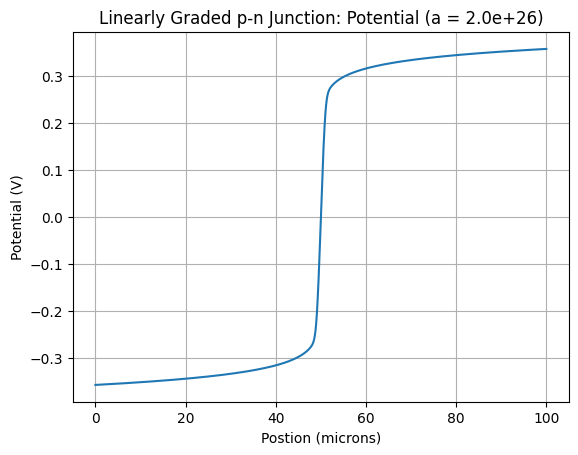

In [12]:
plt.figure()
plt.plot(x*1e6, phi)
plt.ylabel("Potential (V)")
plt.xlabel ("Postion (microns)")
plt.title(f"Linearly Graded p-n Junction: Potential (a = {a:.1e})")
plt.grid(True)
plt.show()

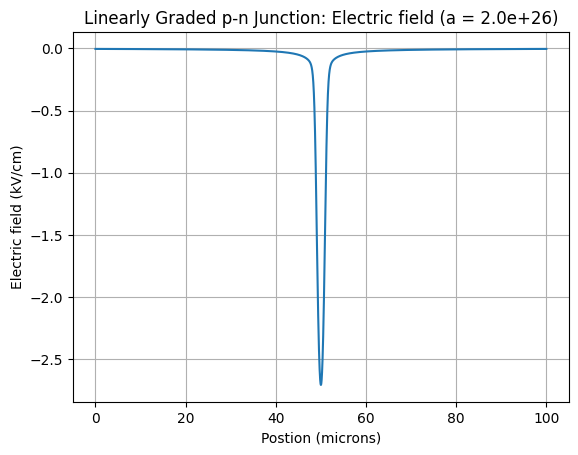

In [13]:
plt.figure()
plt.plot(x*1e6, E/1e5)
plt.ylabel("Electric field (kV/cm)")
plt.xlabel ("Postion (microns)")
plt.title(f"Linearly Graded p-n Junction: Electric field (a = {a:.1e})")
plt.grid(True)
plt.show()

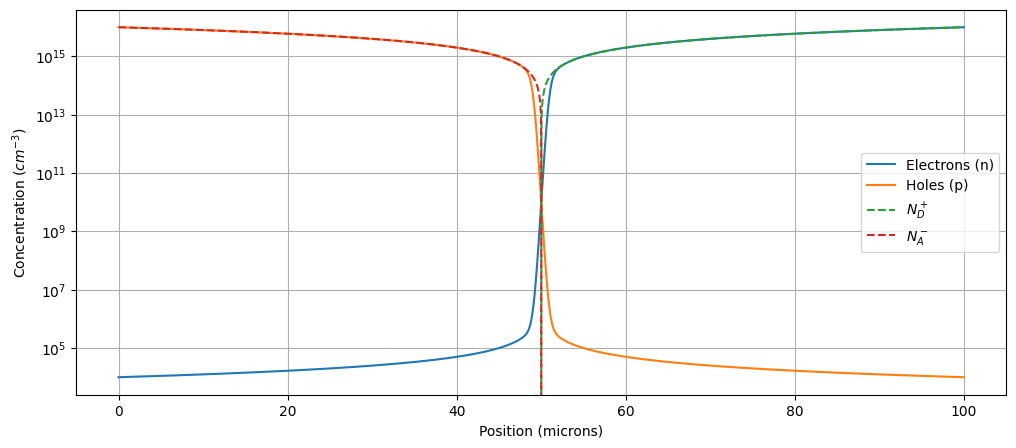

In [14]:
plt.figure(figsize=(12,5))
plt.semilogy(x*1e6, n/1e6, label = "Electrons (n)")
plt.semilogy(x*1e6, p/1e6, label = "Holes (p)")
plt.semilogy(x * 1e6, num_ND_plus_ions/1e6, "--", label="$N_D^+$")
plt.semilogy(x * 1e6, num_NA_minus_ions/1e6, "--", label="$N_A^-$")
plt.ylabel("Concentration ($cm^{-3}$)")
plt.xlabel("Position (microns)")
plt.legend()
plt.grid(True)
plt.show()

Unlike the abrupt-junction model, the doping profile varies continuously throughout the junction, producing smoothly varying charge, potential, electric field, and carrier concentration profiles